In [26]:
import numpy as np, ast, pandas as pd, networkx as nx, matplotlib.pyplot as plt
from calibration_helpers import load_payload
from networkx.drawing.nx_agraph import graphviz_layout

In [27]:
QV_THRESHOLD = 2 / 3
Z_97 = 1.88  # one-sided 97% z-value

$SE_{combined} = \sqrt{\frac{1}{k^2}\sum_{i=1}^{n} e_i^2 } = \frac{1}{k}\sqrt{\sum_{i=1}^{n} e_i^2 }$

That means Qiskit is barely trying to improve the mapped circuit. 

```python
layout_method="trivial"
routing_method="basic"
optimization_level=0
```

For QV, each layer is built from random SU(4) two-qubit blocks after a random permutation, and for odd widths one qubit is idle each layer. On a connected 3-qubit path like (a, b, c), one of the possible two-qubit interactions is between the two endpoints. That interaction is not native, so with trivial layout and basic routing it tends to introduce SWAP overheadresulting in extra routing cost that can dominate the whole layer. 3Q layers contain only one gate, so routing dominates. 4Q layers contain two gates, allowing routing overhead to be shared.

In [28]:
def coupling_to_graph(coupling_map):
    G = nx.Graph()
    G.add_edges_from((int(a), int(b)) for a, b in coupling_map)
    return G


def node_scores_from_subsets(df):
    node_vals = {}
    node_errs = {}
    node_counts = {}

    for _, row in df.iterrows():
        subset = ast.literal_eval(row["subset"])

        score = float(row["mean_HOP"])
        err   = float(row["hop_error"])

        for node in subset:
            if node not in node_vals:
                node_vals[node] = []
                node_errs[node] = []
                node_counts[node] = 0

            node_vals[node].append(score)
            node_errs[node].append(err)
            node_counts[node] += 1

    score = {}
    error = {}

    for n in node_vals:
        vals = np.array(node_vals[n])
        errs = np.array(node_errs[n])
        k = len(vals)

        score[n] = float(np.mean(vals))
        error[n] = float(np.sqrt(np.sum(errs**2)) / k)  

    return score, error


def plot_node_heatmap(G, pos, score, error):
    nodes = list(G.nodes())
    vals = np.array([score.get(n, np.nan) for n in nodes], dtype=float)
    errs = np.array([error.get(n, 0.0) for n in nodes], dtype=float)

    # QV lower bound
    lower_bound = vals - Z_97 * errs

    # margin relative to QV threshold
    margin = lower_bound - QV_THRESHOLD

    vmax = np.nanmax(np.abs(margin))
    norm = plt.Normalize(vmin=-vmax, vmax=vmax)

    cmap = plt.cm.coolwarm

    fig, ax = plt.subplots(figsize=(16, 8))

    colors = cmap(norm(margin))

    nx.draw(
        G, pos, ax=ax,
        node_color=colors,
        with_labels=True,
        node_size=350,
        width=1
    )

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    fig.colorbar(sm, ax=ax, label="QV margin (lower bound − 2/3)")

    ax.set_title("Node heatmap (QV confidence margin)")
    ax.set_axis_off()
    fig.tight_layout()
    plt.show()

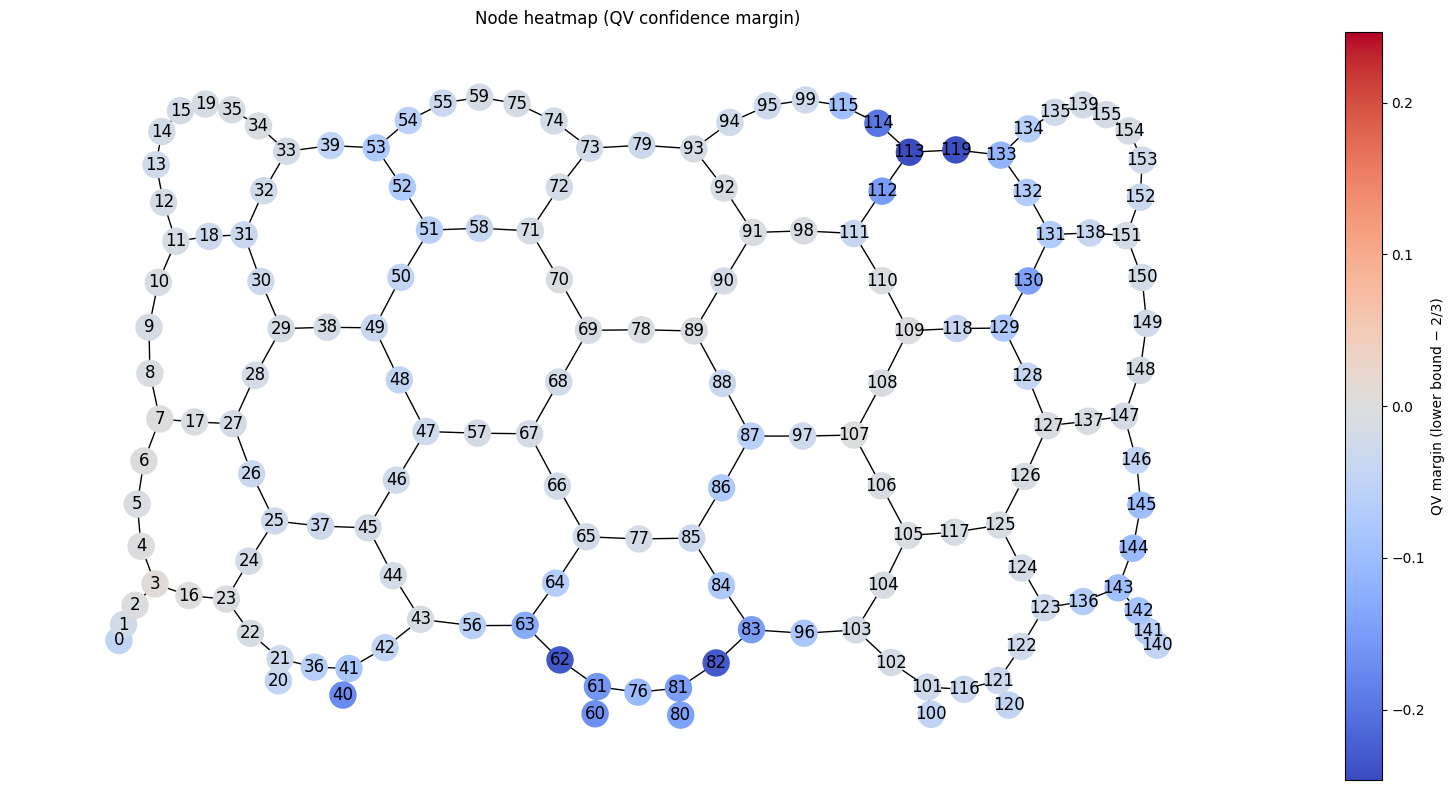

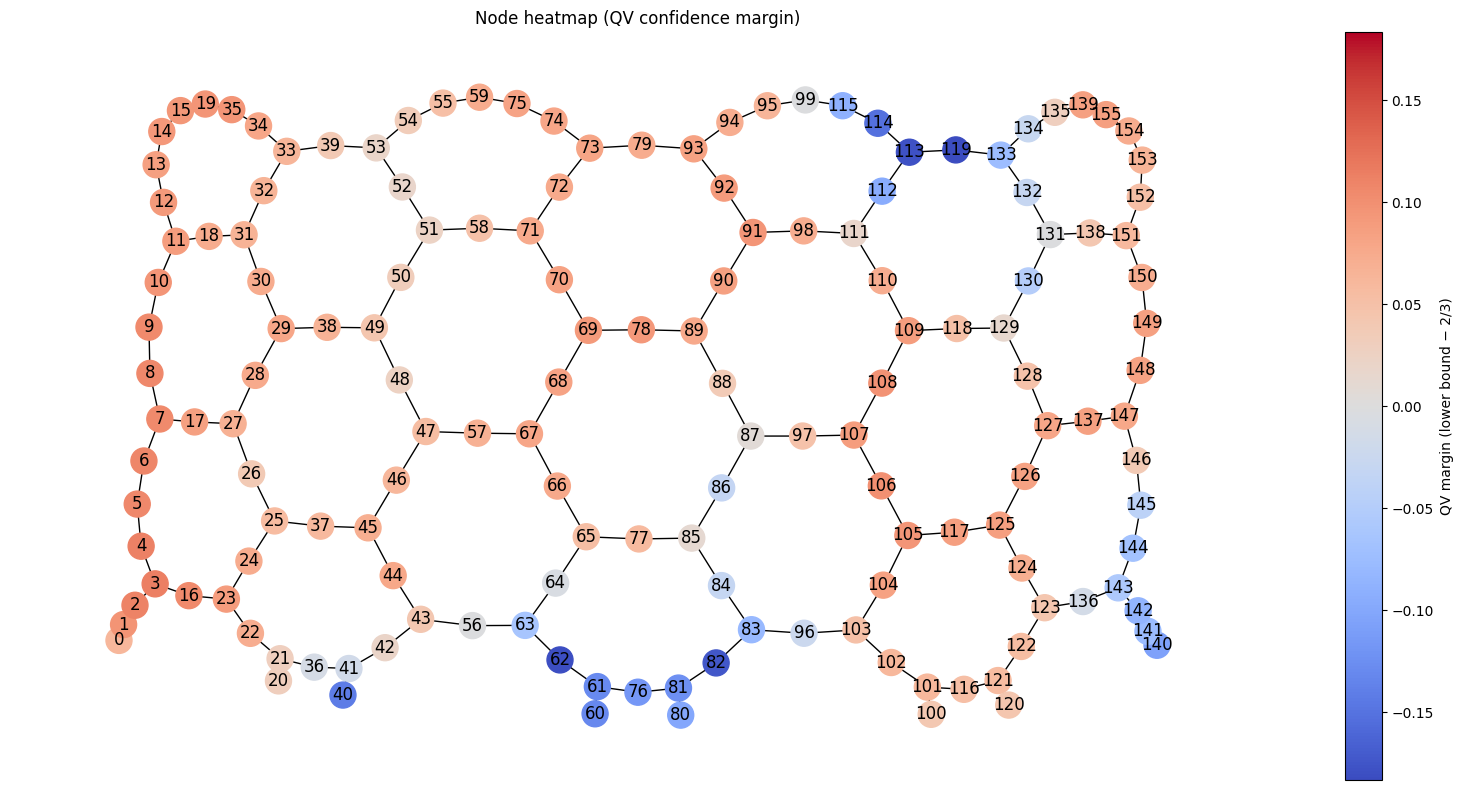

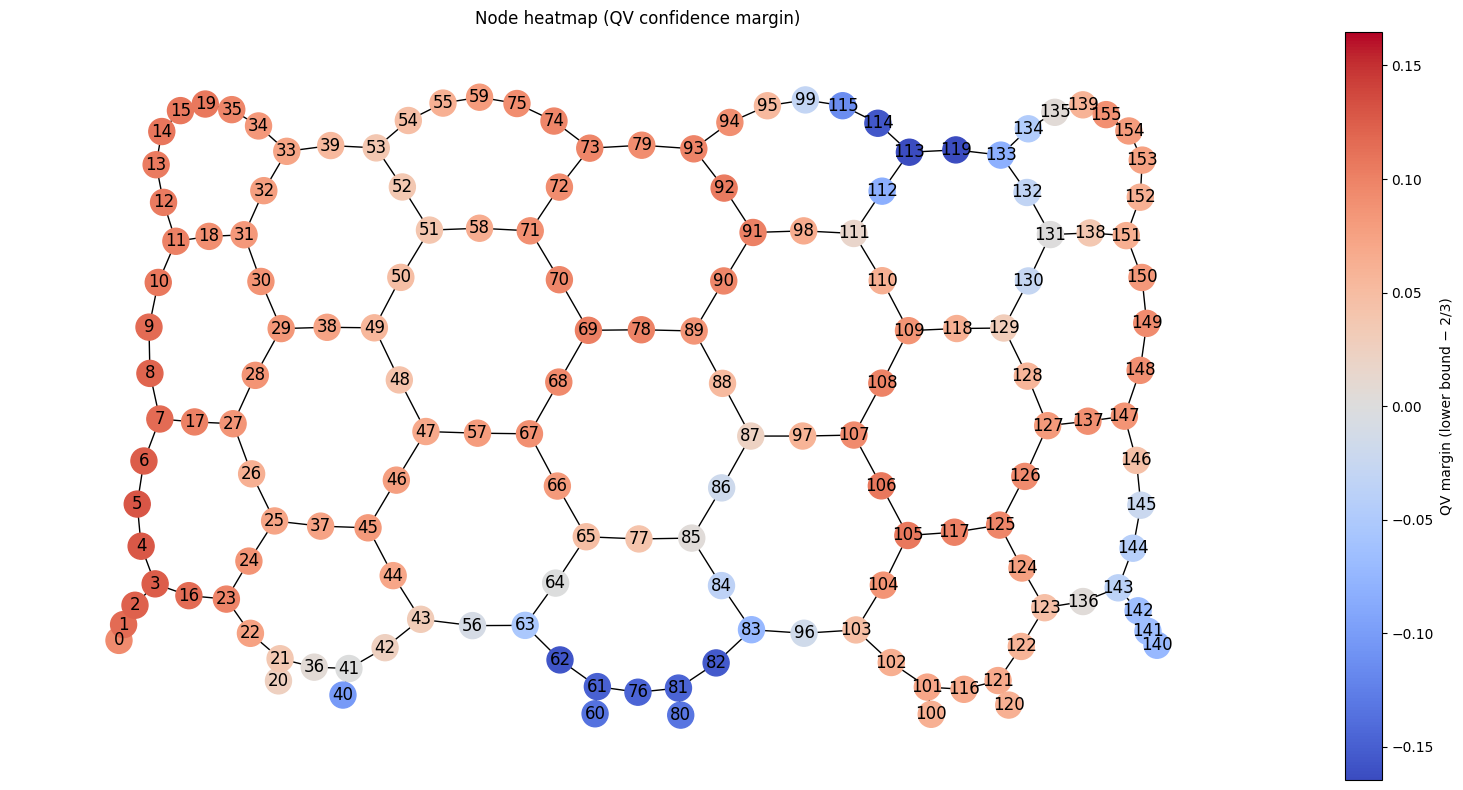

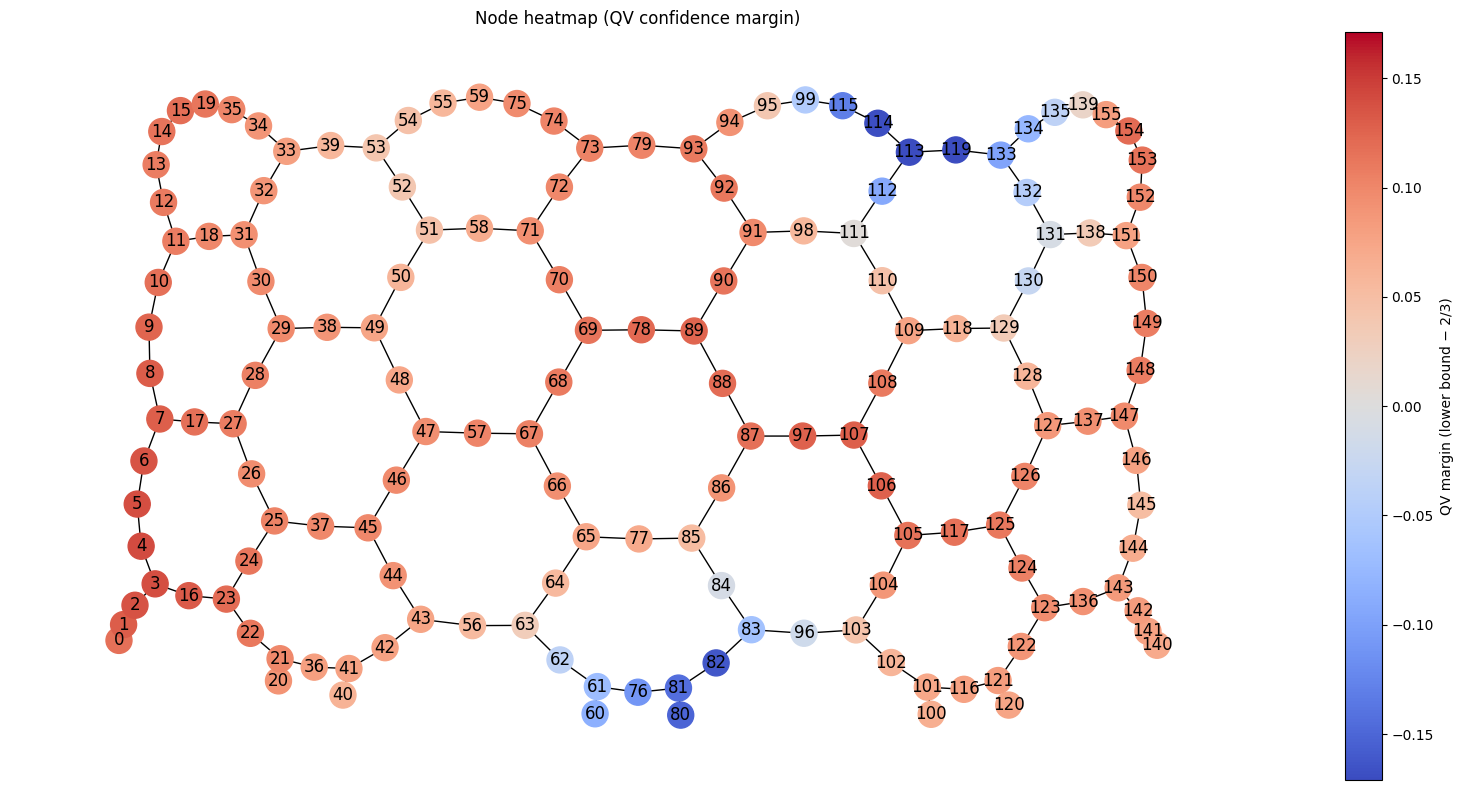

In [29]:
calibration = "calibrations/ibm_marrakesh/20260129_101824.json"
payload = load_payload(calibration)
coupling_map = payload["coupling_map"]

G = coupling_to_graph(coupling_map)
pos = graphviz_layout(G, prog="sfdp")

for q in [3, 4, 5, 6]:
    df = pd.read_csv(f"results/ibm_marrakesh_qv_{q}_tuples.csv")
    score, error = node_scores_from_subsets(df)
    plot_node_heatmap(G, pos, score, error)

In [30]:
def node_qv_success_counts(df, z=Z_97, threshold=QV_THRESHOLD):
    total = {}
    success = {}

    for _, row in df.iterrows():
        subset = ast.literal_eval(row["subset"])

        mean_hop = float(row["mean_HOP"])
        hop_err  = float(row["hop_error"])

        lower_bound = mean_hop - z * hop_err
        is_success = lower_bound > threshold

        for q in subset:
            total[q] = total.get(q, 0) + 1
            if is_success:
                success[q] = success.get(q, 0) + 1

    fraction = {q: success.get(q, 0) / total[q] for q in total}

    return success, total, fraction

In [31]:
def plot_qv_success_count_heatmap(G, pos, success, total):
    nodes = list(G.nodes())

    vals = np.array([success.get(n, 0) for n in nodes], dtype=float)

    vmin = 0
    vmax = float(np.max(vals))
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    cmap = plt.cm.plasma
    colors = cmap(norm(vals))

    fig, ax = plt.subplots(figsize=(16, 8))

    nx.draw_networkx_nodes(
        G, pos,
        node_color=colors,
        node_size=500,
        ax=ax
    )

    nx.draw_networkx_edges(G, pos, width=1, ax=ax)

    for node, (x, y), val in zip(nodes, pos.values(), vals):
        r, g, b, _ = cmap(norm(val))

        brightness = 0.299*r + 0.587*g + 0.114*b
        text_color = "black" if brightness > 0.6 else "white"

        ax.text(
            x, y,
            str(node),
            ha="center",
            va="center",
            fontsize=9,
            color=text_color,
            fontweight="bold"
        )

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    fig.colorbar(sm, ax=ax, label="number of successful subsets")

    ax.set_title("Node heatmap (QV-success count)")
    ax.set_axis_off()

    fig.tight_layout()
    plt.show()

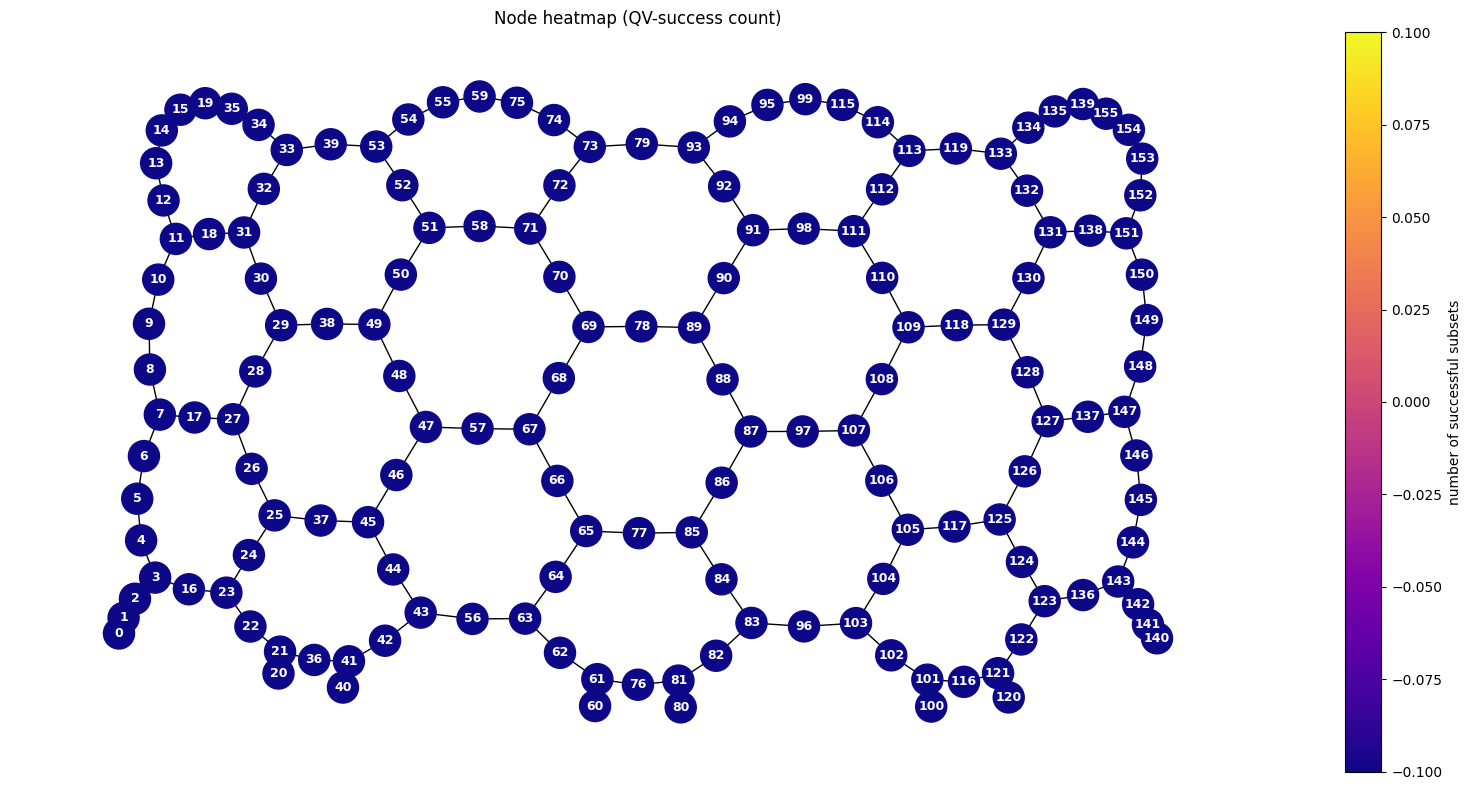

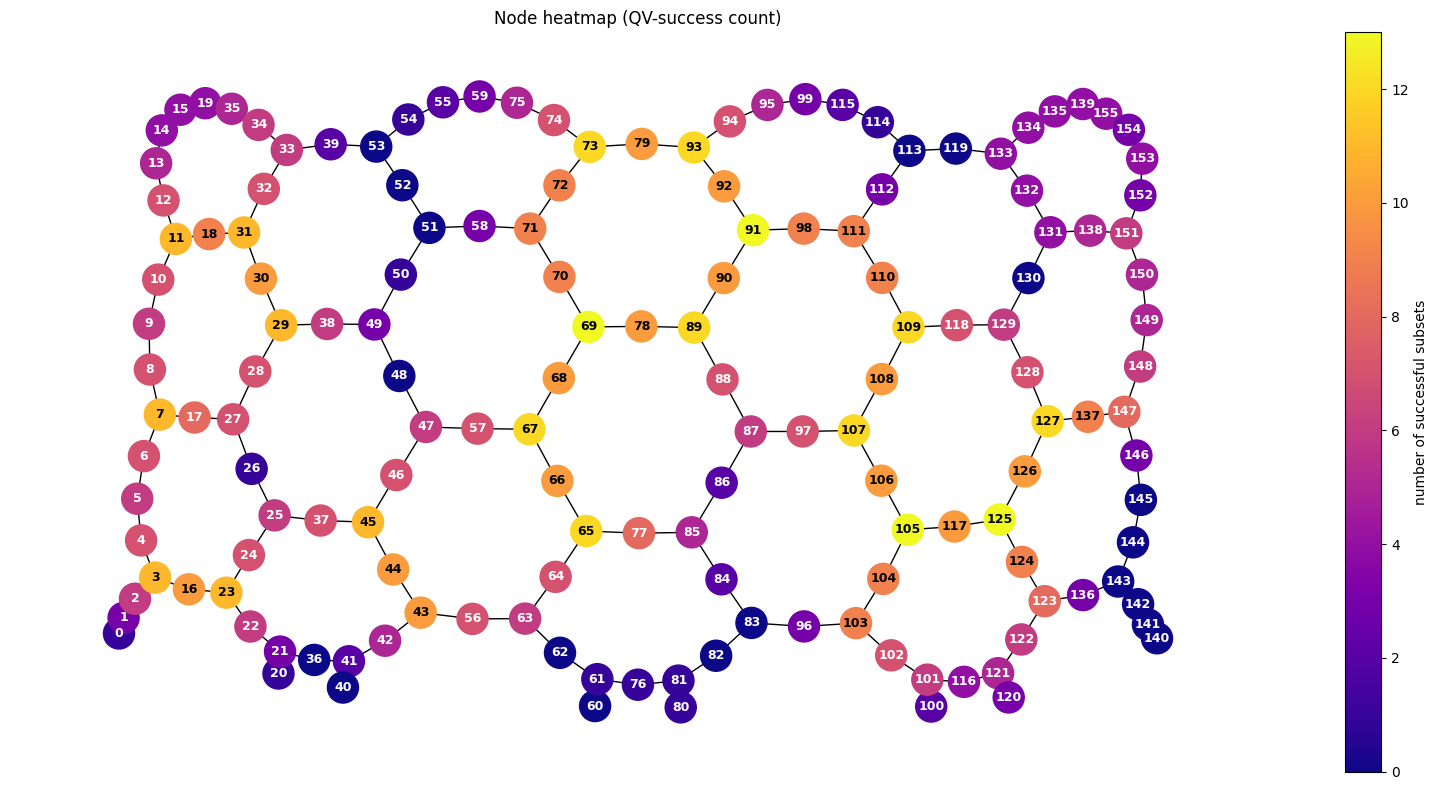

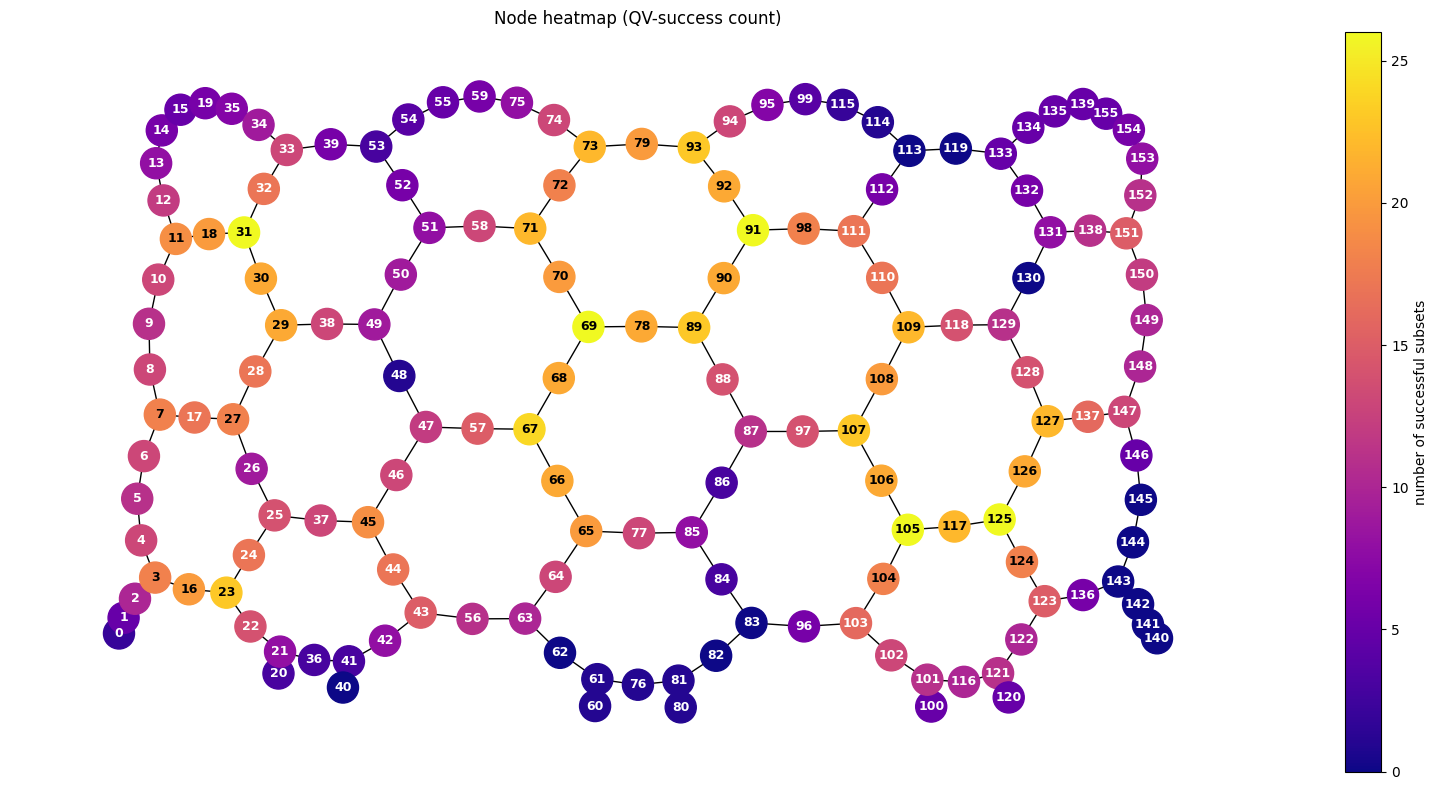

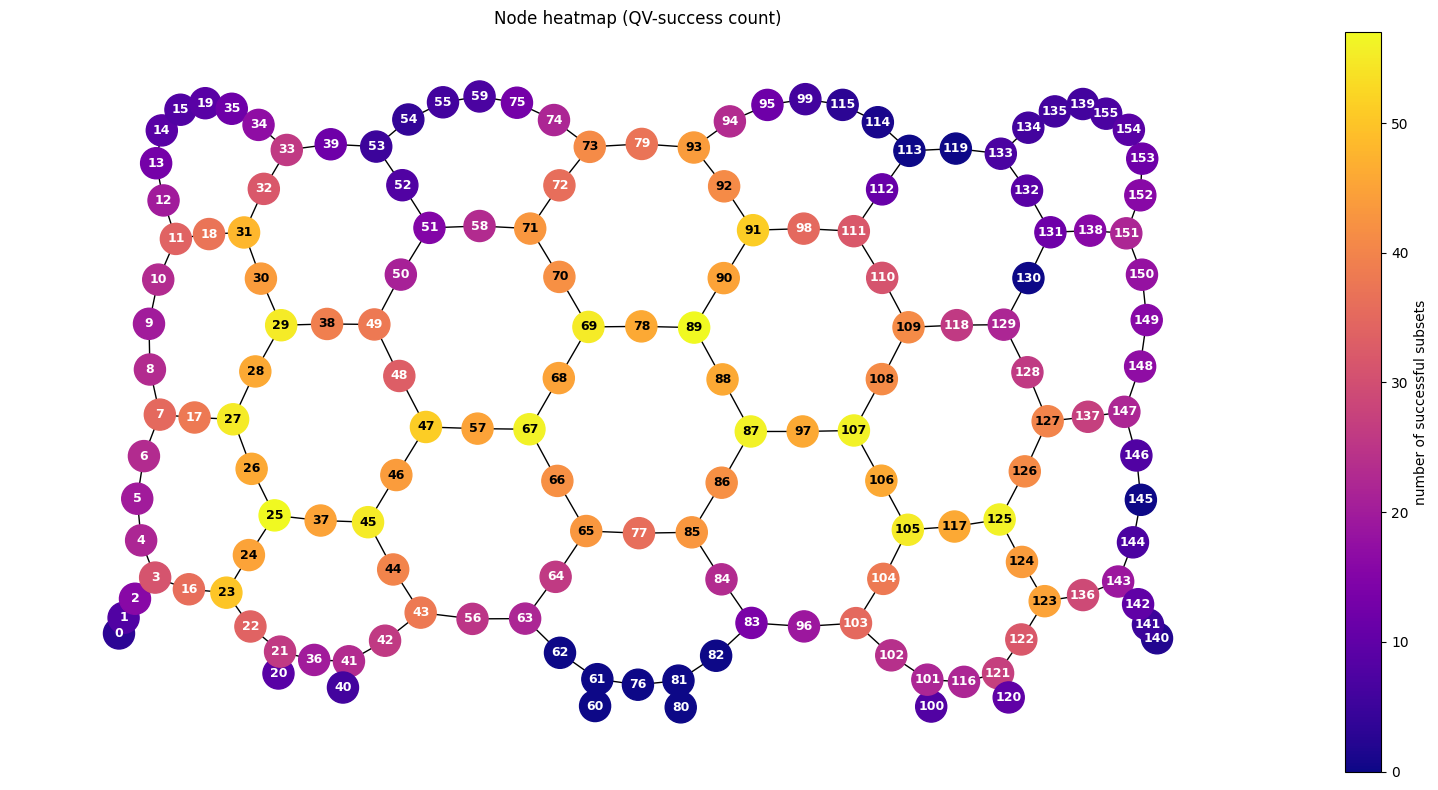

In [32]:
for q in [3, 4, 5, 6]:
    df = pd.read_csv(f"results/ibm_marrakesh_qv_{q}_tuples.csv")

    success, total, fraction = node_qv_success_counts(df)

    plot_qv_success_count_heatmap(G, pos, success, total)